In [1]:
#Part:1 — What is a Tensor
#Everything in deep learning is numbers. Images, text, audio — all converted to numbers first.

import numpy as np
X= 42
print("scalar:", X)



    

scalar: 42


In [2]:
# a list of numbers in 1-D is known as vector
marks = [67, 68, 78, 89, 93]
print("vector:", marks)

vector: [67, 68, 78, 89, 93]


In [3]:
# A table of numbers — matrix (2D)
# Think of this as 3 students, 3 features each
students = [
    [8, 90, 9],   # student 1: cgpa, attendance, assignments
    [6, 70, 7],   # student 2
    [4, 45, 3],   # student 3
]
print("matrix:")
print(np.array(students))

matrix:
[[ 8 90  9]
 [ 6 70  7]
 [ 4 45  3]]


In [4]:
images = np.zeros((5, 28, 28))
print("3D shape:", images.shape)

3D shape: (5, 28, 28)


NameError: name 'true' is not defined

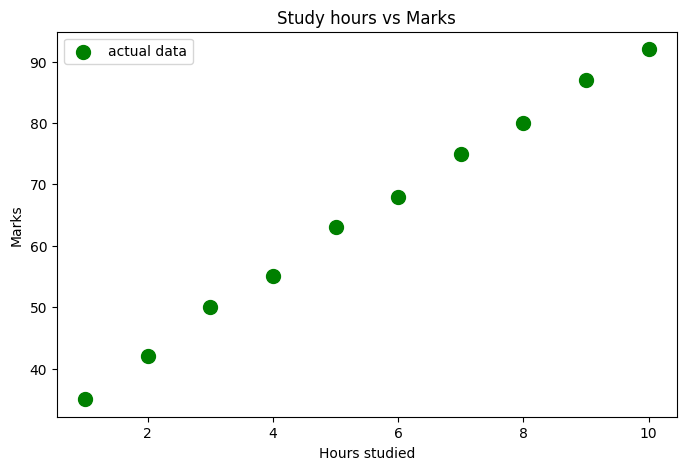

In [5]:
import numpy as np
import matplotlib.pyplot as plt
hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
marks  = np.array([35, 42, 50, 55, 63, 68, 75, 80, 87, 92])
plt.figure(figsize=(8, 5))
plt.scatter(hours, marks, color='green', s=100, label='actual data')
plt.xlabel('Hours studied')
plt.ylabel('Marks')
plt.title('Study hours vs Marks')
plt.legend()
plt.grid(true)
plt.show()

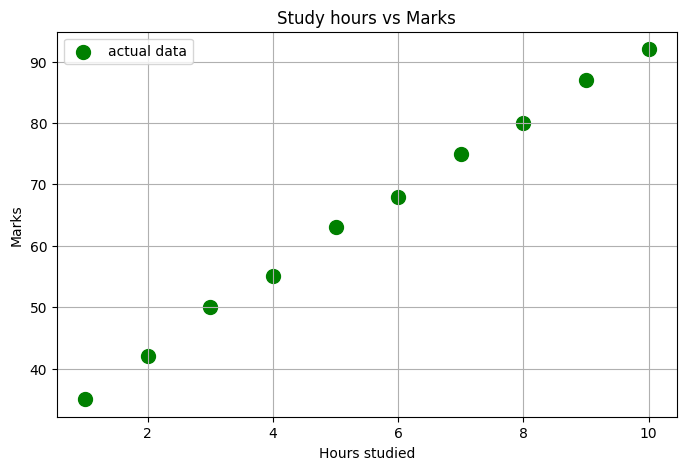

In [6]:
import numpy as np
import matplotlib.pyplot as plt
hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
marks  = np.array([35, 42, 50, 55, 63, 68, 75, 80, 87, 92])
plt.figure(figsize=(8, 5))
plt.scatter(hours, marks, color='green', s=100, label='actual data')
plt.xlabel('Hours studied')
plt.ylabel('Marks')
plt.title('Study hours vs Marks')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
m = 5
c = 30

predicted = m*hours + c
print("Hours | Predicted | Actual | Error")
print("-"* 45)

for i in range(len(hours)):
    error = marks[i] - predicted[i]
    print(f" {hours[i]:4} | {marks[i]:6} | {predicted[i]:9} | {error[i]:5.1f}")
    

Hours | Predicted | Actual | Error
---------------------------------------------


IndexError: invalid index to scalar variable.

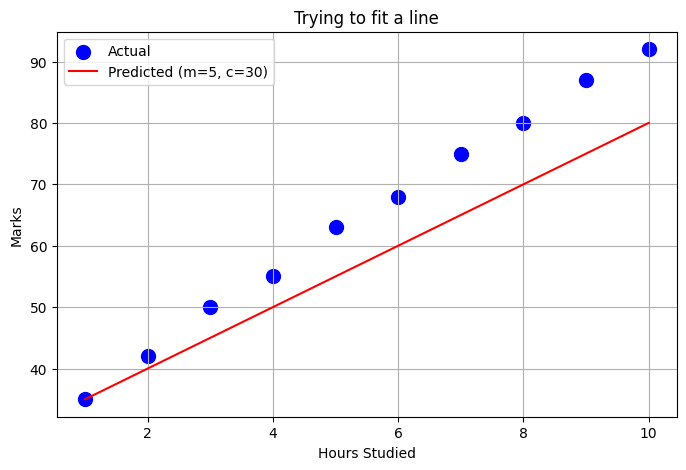

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(hours, marks, color='blue', s=100, label='Actual')
plt.plot(hours, predicted, color='red', label=f'Predicted (m={m}, c={c})')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Trying to fit a line')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
def calculate_loss(m, c, hours, marks):
    predicted = m * hours + c
    error = marks - predicted
    squared_errors = errors ** 2
    loss = np.mean(squared_errors)
    return loss

print("trying different values of m & c:")
print(f"{'m':>5} {'c':>5} {'Loss':>12}")
print("-" * 25)

test_values = [
    (5, 30),
    (6, 28),
    (5.5, 29),
    (6.2, 26),
    (5.8, 27),
]

for m, c in test_values:
    loss = calculate_loss(m, c, hours, marks)
    print(f"{m:>5} {c:>5} {loss:>12.2f}")

trying different values of m & c:
    m     c         Loss
-------------------------


NameError: name 'errors' is not defined

In [10]:
def calculate_loss(m, c, hours, marks):
    predicted = m * hours + c
    error = marks - predicted
    squared_error = error ** 2
    loss = np.mean(squared_error)
    return loss

print("trying different values of m & c:")
print(f"{'m':>5} {'c':>5} {'Loss':>12}")
print("-" * 25)

test_values = [
    (5, 30),
    (6, 28),
    (5.5, 29),
    (6.2, 26),
    (5.8, 27),
]

for m, c in test_values:
    loss = calculate_loss(m, c, hours, marks)
    print(f"{m:>5} {c:>5} {loss:>12.2f}")

trying different values of m & c:
    m     c         Loss
-------------------------
    5    30        67.00
    6    28        15.30
  5.5    29        36.02
  6.2    26        22.04
  5.8    27        36.64


In [11]:
def gradient_descent(hours, marks, 
                     learning_rate=0.001, 
                     epochs=1000):
    m = 0.0
    c = 0.0
    n = len(hours)

    loss_history = []
    for epoch in range(epochs):
        predicted = m * hours + c
        loss = np.mean((marks - predicted) ** 2)
        loss_history.append(loss)
        
        dm = (-2/n) * np.sum(hours * (marks - predicted))
        dc = (-2/n) * np.sum(marks - predicted)
        
        m = m - learning_rate * dm
        c = c - learning_rate * dc
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | "
                  f"Loss: {loss:8.2f} | "
                  f"m: {m:.4f} | "
                  f"c: {c:.4f}")
    
    return m, c, loss_history

print("Starting gradient descent...")
print(f"{'Epoch':>6} | {'Loss':>10} | {'m':>8} | {'c':>8}")
print("-" * 45)

m_final, c_final, losses = gradient_descent(
    hours, marks, 
    learning_rate=0.001, 
    epochs=1000
)

print(f"\nFinal values: m={m_final:.4f}, c={c_final:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
        
    


Starting gradient descent...
 Epoch |       Loss |        m |        c
---------------------------------------------
Epoch    0 | Loss:  4516.50 | m: 0.8160 | c: 0.1294
Epoch  100 | Loss:   160.12 | m: 10.2338 | c: 2.6756
Epoch  200 | Loss:   147.28 | m: 10.0754 | c: 3.7972
Epoch  300 | Loss:   135.47 | m: 9.9210 | c: 4.8723
Epoch  400 | Loss:   124.62 | m: 9.7729 | c: 5.9032
Epoch  500 | Loss:   114.64 | m: 9.6309 | c: 6.8916
Epoch  600 | Loss:   105.46 | m: 9.4948 | c: 7.8394
Epoch  700 | Loss:    97.02 | m: 9.3642 | c: 8.7482
Epoch  800 | Loss:    89.27 | m: 9.2391 | c: 9.6197
Epoch  900 | Loss:    82.14 | m: 9.1191 | c: 10.4553

Final values: m=9.0051, c=11.2486
Final loss: 75.6409


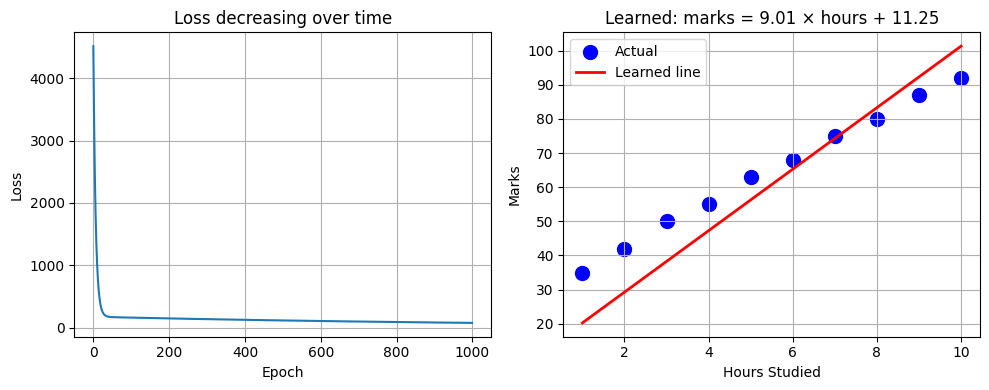

In [12]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss decreasing over time')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(hours, marks, 
            color='blue', s=100, label='Actual')
predicted_final = m_final * hours + c_final
plt.plot(hours, predicted_final, 
         color='red', linewidth=2, label='Learned line')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title(f'Learned: marks = {m_final:.2f} × hours + {c_final:.2f}')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
def predict_marks(hours_studied, m, c):
    return m * hours_studied + c

    test_cases = [3.5, 5.5, 7.5, 11, 0.5]

print("Predictions for new students:")
print(f"{'Hours':>8} | {'Predicted Marks':>15}")
print("-" * 27)

for h in test_cases:
    predicted = predict_marks(h, m_final, c_final)
    # Clip between 0 and 100
    predicted = max(0, min(100, predicted))
    print(f"{h:>8} | {predicted:>15.1f}")

Predictions for new students:
   Hours | Predicted Marks
---------------------------


NameError: name 'test_cases' is not defined

In [14]:
def predict_marks(hours_studied, m, c):
    return m * hours_studied + c

test_cases = [3.5, 5.5, 7.5, 11, 0.5]

print("Predictions for new students:")
print(f"{'Hours':>8} | {'Predicted Marks':>15}")
print("-" * 27)

for h in test_cases:
    predicted = predict_marks(h, m_final, c_final)
    # Clip between 0 and 100
    predicted = max(0, min(100, predicted))
    print(f"{h:>8} | {predicted:>15.1f}")

Predictions for new students:
   Hours | Predicted Marks
---------------------------
     3.5 |            42.8
     5.5 |            60.8
     7.5 |            78.8
      11 |           100.0
     0.5 |            15.8


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

hours  = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
marks  = np.array([35,42,50,55,63,68,75,80,87,92])

model = LinearRegression()
model.fit(hours, marks)

print(f"Sklearn found: m={model.coef_[0]:.4f}, "
      f"c={model.intercept_:.4f}")

predictions = model.predict(hours)

mse = mean_squared_error(marks, predictions)
r2  = r2_score(marks, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"(R² of 1.0 = perfect, 0.0 = terrible)")

new_student = np.array([[6.5]])
print(f"\nStudent who studies 6.5 hours: "
      f"{model.predict(new_student)[0]:.1f} marks")

Sklearn found: m=6.3212, c=29.9333
Mean Squared Error: 0.76
R² Score: 0.9977
(R² of 1.0 = perfect, 0.0 = terrible)

Student who studies 6.5 hours: 71.0 marks


In [16]:
hours_studied = np.array([1,2,3,4,5,6,7,8,9,10])
attendance    = np.array([60,65,70,72,75,80,82,85,90,95])
marks         = np.array([35,42,50,55,63,68,75,80,87,92])

X = np.column_stack([hours_studied, attendance])
y = marks

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Coefficients (m1, m2):", model.coef_)
print("Intercept (c):", model.intercept_)

new_student = np.array([[6, 78]])
print(f"\nPredicted marks: {model.predict(new_student)[0]:.1f}")

Coefficients (m1, m2): [6.00076628 0.08812261]
Intercept (c): 24.87509578544045

Predicted marks: 67.8
